 # **Milestone 2: Data Visualization on Machine Learning Solution Project**



---



Milestone 2 requires you to generate data visualizations of your Milestone 1 using Matplotlib and Seaborn.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import pandas as pd

customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')
socmed_interactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df3.csv')

## **Customer Demographics**


---


Columns:
* **CustomerID**: Unique identifier for each customer.
* **Age**: Numerical value representing the age of the customer.
* **Gender**: Categorical value indicating the gender of the customer.
* **Location**: Categorical value representing the geographic location of the customer.
* **IncomeLevel**: Categorical or numerical representation of the customer's income level.
* **SignupDate**: Date representing when the customer registered or signed up.



In [ ]:
import pandas as pd

customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')

### **Age Distribution**

Analyze how customers are distributed across different age groups.

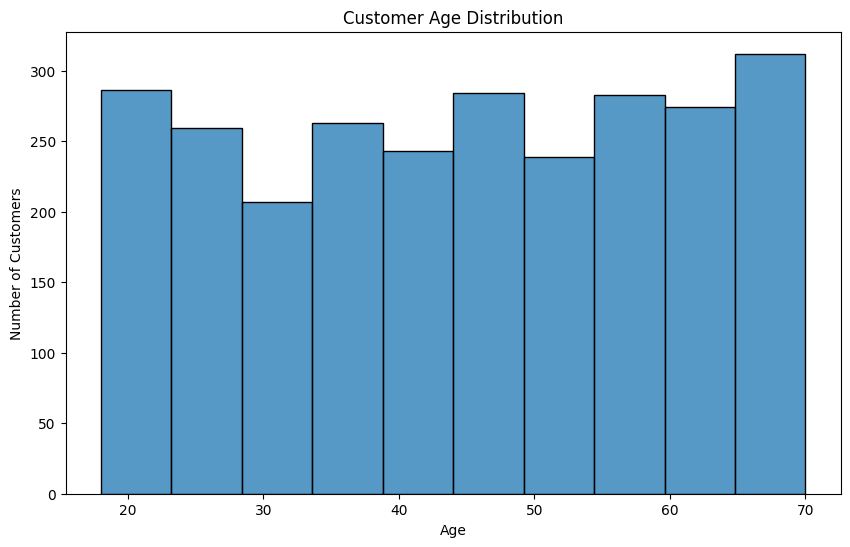

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(customer_demographics['Age'], bins=10)
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()


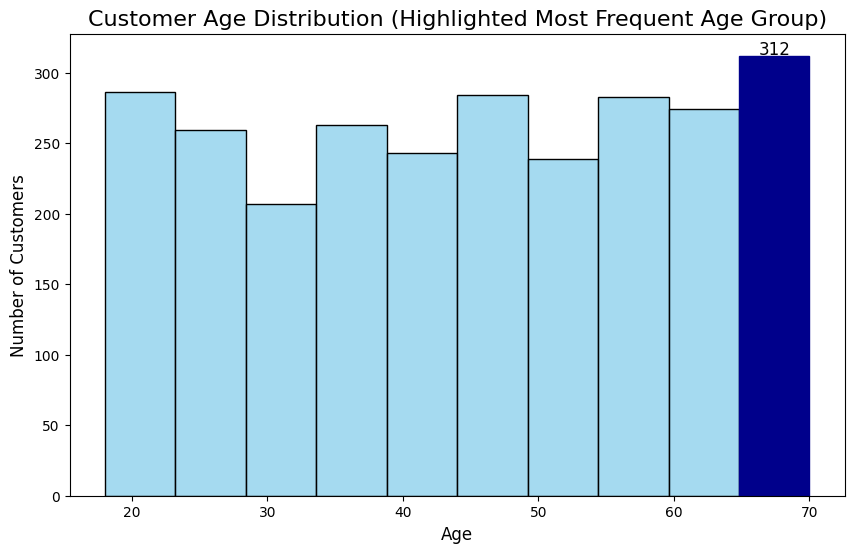

In [ ]:
# Create the histogram for customer age distribution
plt.figure(figsize=(10, 6))

# Plot the histogram and store the return value to capture the bins
histplot = sns.histplot(customer_demographics['Age'], bins=10, color='skyblue')

# Calculate the bin with the highest count (most frequent age group)
max_count = 0
max_rect = None
for rect in histplot.patches:
    height = rect.get_height()
    if height > max_count:
        max_count = height
        max_rect = rect

# Highlight the bin with the most counts by changing its color to dark blue
max_rect.set_color('darkblue')

# Annotate the bin with the highest count
plt.text(
    max_rect.get_x() + max_rect.get_width() / 2,    # x-coordinate at the center of the bar
    max_rect.get_height() + 1,                      # y-coordinate slightly above the bar
    f'{int(max_rect.get_height())}',                # The count text
    ha='center',                                    # Align text in the center
    fontsize=12,                                    # Text size
    color='black'                                   # Text color
)

# Add title and labels to the plot
plt.title('Customer Age Distribution (Highlighted Most Frequent Age Group)', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Show the plot
plt.show()


### **Gender Distribution**

In [ ]:
import plotly.express as px

# Define a custom color palette (e.g., shades of blue for better contrast)
custom_colors = ['#c90076', '#2986cc']  # Example: Blue for Male, Orange for Female

# Create a donut chart with the custom color palette
fig = px.pie(customer_demographics,
             names='Gender',
             title='Customer Gender Distribution',
             hole=0.4,  # This creates the hole for a donut chart
             labels={'Gender': 'Gender'},
             color_discrete_sequence=custom_colors)  # Apply custom colors

# Update the text to include both the percentage and the actual count inside the segments
fig.update_traces(textinfo='percent+label',  # Show both percentage and label (Male/Female)
                  hoverinfo='label+percent+value',  # Show label, percent, and actual count on hover
                  textposition='inside')  # Place text inside the donut

# Show the chart
fig.show()


### **Customer Signup Trends Over Time**

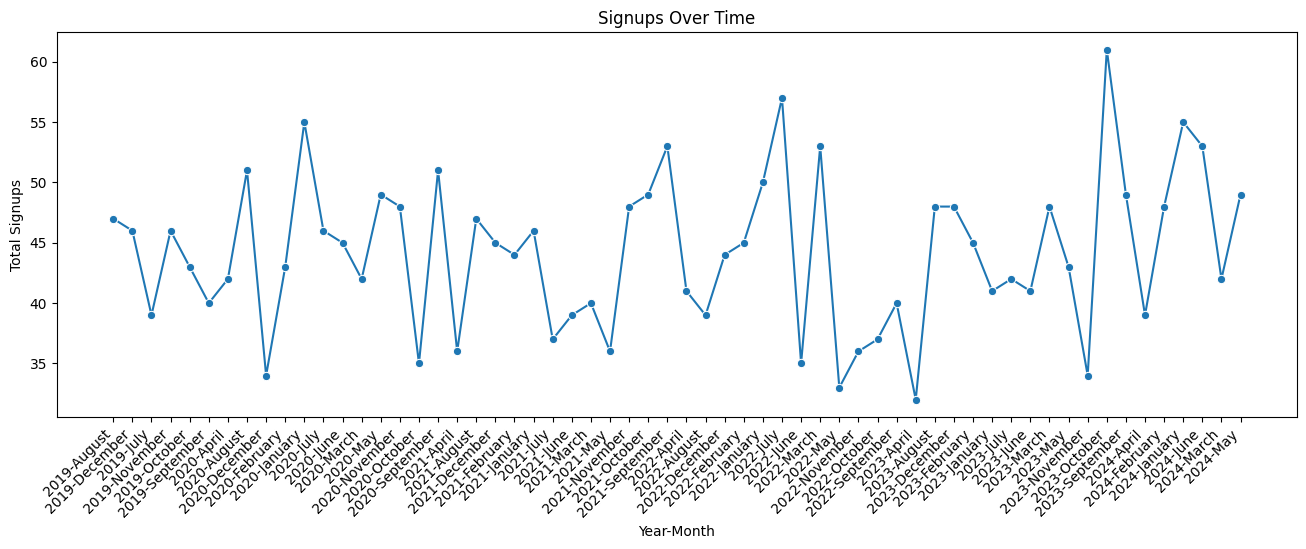

In [ ]:
# Load the customer demographics dataset from a CSV file
customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')

# Make a copy of the original customer demographics data to preserve the original dataset
cust_demo2 = customer_demographics.copy()

# Convert the 'SignupDate' column to a datetime format (allowing for different date formats using 'mixed')
cust_demo2['SignupDate'] = pd.to_datetime(cust_demo2['SignupDate'], format='mixed')

# Extract the year from the 'SignupDate' column and store it in a new 'SignupYear' column
cust_demo2['SignupYear'] = cust_demo2['SignupDate'].dt.year

# Extract the month name from the 'SignupDate' column and store it in a new 'SignupMonth' column
cust_demo2['SignupMonth'] = cust_demo2['SignupDate'].dt.month_name()

# Group the data by 'SignupYear' and 'SignupMonth', counting the number of signups per year-month
signup = cust_demo2.groupby(['SignupYear', 'SignupMonth']).size()

# Reset the index of the resulting grouped data to create a dataframe, and rename the count column to 'Count'
signup = signup.reset_index(name='Count')

# Create a 'YearMonth' column by concatenating 'SignupYear' and 'SignupMonth' for better grouping
signup['YearMonth'] = signup['SignupYear'].astype(str) + '-' + signup['SignupMonth'].astype(str)

# Set the figure size for the plot (16x5 inches)
plt.figure(figsize=(16, 5))

# Create a line plot to visualize the total number of signups over time (by year and month)
sns.lineplot(x='YearMonth', y='Count', data=signup, marker="o")

# Set the title of the plot
plt.title('Signups Over Time')

# Label the x-axis as 'Year-Month' and the y-axis as 'Total Signups'
plt.xlabel('Year-Month')
plt.ylabel('Total Signups')

# Rotate the x-axis labels by 45 degrees and align them to the right for better readability
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.show()

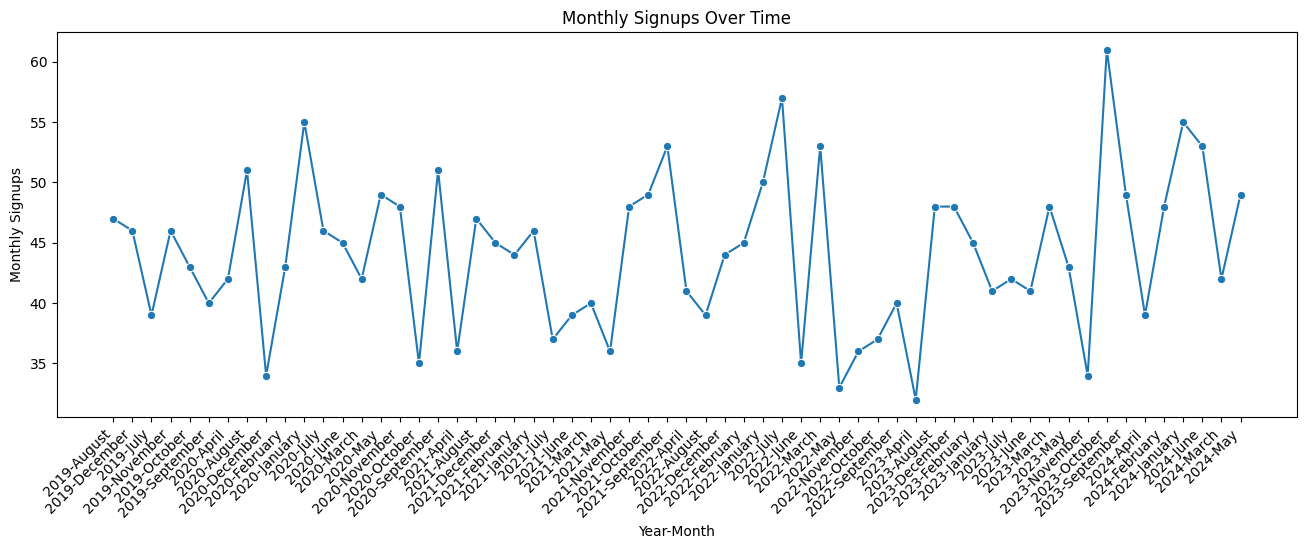

<ipython-input-16-ca33b686570e>:44: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




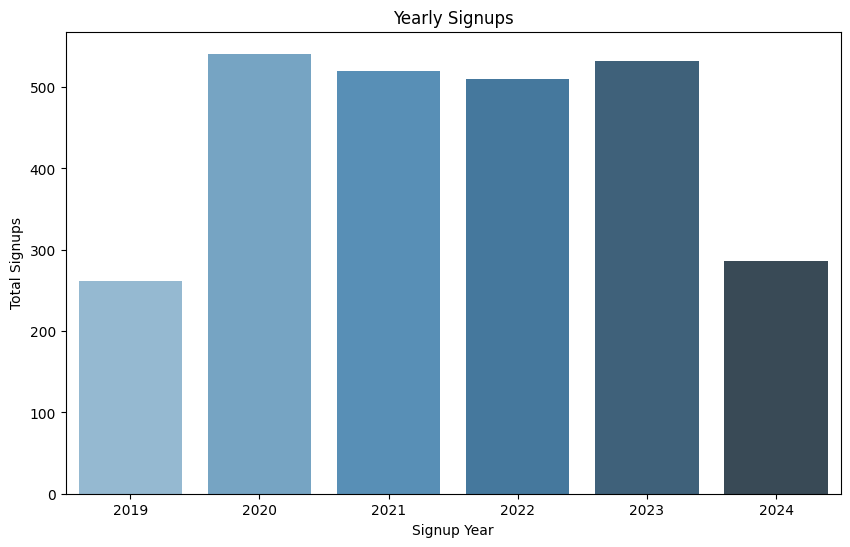

<ipython-input-16-ca33b686570e>:58: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




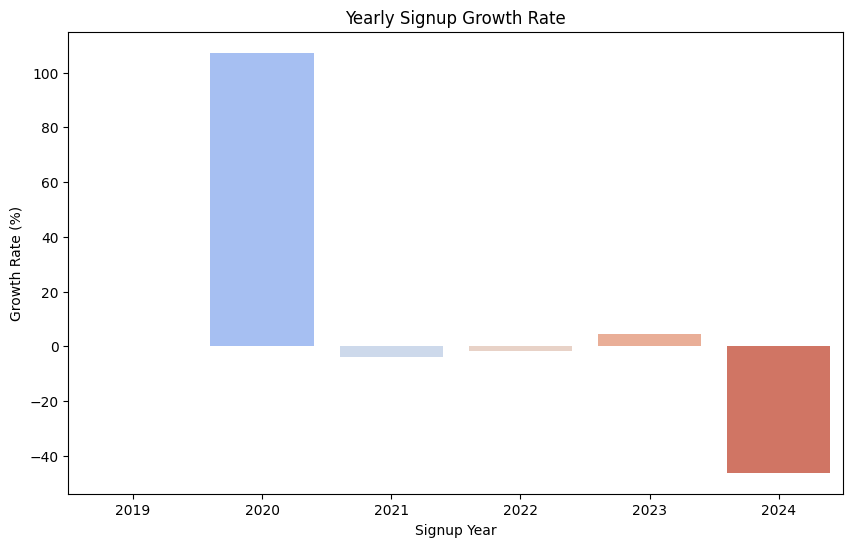

   SignupYear  YearlySignups  GrowthRate
0        2019            261         NaN
1        2020            541  107.279693
2        2021            520   -3.881701
3        2022            510   -1.923077
4        2023            532    4.313725
5        2024            286  -46.240602


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the customer demographics dataset from a CSV file
customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')

# Make a copy of the original customer demographics data to preserve the original dataset
cust_demo2 = customer_demographics.copy()

# Convert the 'SignupDate' column to a datetime format
cust_demo2['SignupDate'] = pd.to_datetime(cust_demo2['SignupDate'], format='mixed')

# Extract the year and month from the 'SignupDate' column
cust_demo2['SignupYear'] = cust_demo2['SignupDate'].dt.year
cust_demo2['SignupMonth'] = cust_demo2['SignupDate'].dt.month_name()

# --------------------------
# Monthly Signups Calculation
# --------------------------
# Group the data by 'SignupYear' and 'SignupMonth', counting the number of signups per year-month
monthly_signup = cust_demo2.groupby(['SignupYear', 'SignupMonth']).size().reset_index(name='MonthlySignups')

# Create a 'YearMonth' column by concatenating 'SignupYear' and 'SignupMonth' for better grouping
monthly_signup['YearMonth'] = monthly_signup['SignupYear'].astype(str) + '-' + monthly_signup['SignupMonth'].astype(str)

# Plot Monthly Signups
plt.figure(figsize=(16, 5))
sns.lineplot(x='YearMonth', y='MonthlySignups', data=monthly_signup, marker="o")
plt.title('Monthly Signups Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Monthly Signups')
plt.xticks(rotation=45, ha='right')
plt.show()

# --------------------------
# Yearly Signups Calculation
# --------------------------
# Group the data by 'SignupYear' to calculate the total number of signups per year
yearly_signup = cust_demo2.groupby('SignupYear').size().reset_index(name='YearlySignups')

# Plot Yearly Signups
plt.figure(figsize=(10, 6))
sns.barplot(x='SignupYear', y='YearlySignups', data=yearly_signup, palette='Blues_d')
plt.title('Yearly Signups')
plt.xlabel('Signup Year')
plt.ylabel('Total Signups')
plt.show()

# ---------------------------
# Signup Growth Rate Calculation
# ---------------------------
# Calculate the growth rate (percentage change) in signups year over year
yearly_signup['GrowthRate'] = yearly_signup['YearlySignups'].pct_change() * 100

# Plot the Signup Growth Rate
plt.figure(figsize=(10, 6))
sns.barplot(x='SignupYear', y='GrowthRate', data=yearly_signup, palette='coolwarm')
plt.title('Yearly Signup Growth Rate')
plt.xlabel('Signup Year')
plt.ylabel('Growth Rate (%)')
plt.show()

# Display the final Yearly Signups with Growth Rate
print(yearly_signup)


### **Income Level Distribution**

In [15]:
import pandas as pd
import plotly.express as px

customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')

# Instead of using aggregator, directly calculate the counts using pandas and then plot
income_level_counts = customer_demographics['IncomeLevel'].value_counts().reset_index()
income_level_counts.columns = ['IncomeLevel', 'count']  # Rename columns for clarity

# Create a Plotly bar chart using the aggregated data
fig = px.bar(
    income_level_counts,  # Use the aggregated data
    x='IncomeLevel',
    y='count',  # Use the calculated counts
    title='Customer Distribution by Income Level',
    labels={'IncomeLevel': 'Income Level', 'count': 'Number of Customers'},
    color='IncomeLevel',  # Different colors for each income level
    color_discrete_sequence=px.colors.qualitative.Set2  # Similar palette to Seaborn's 'Set2'
)

# Show the chart
fig.show()

In [ ]:
import plotly.express as px

# Create a pie chart for the income level distribution
fig = px.pie(cust_demo2,
             names='IncomeLevel',  # Column for the segments (income levels)
             title='Customer Distribution by Income Level',  # Chart title
             hole=0.4,  # This creates a donut chart; set hole=0 if you want a regular pie chart
             labels={'IncomeLevel': 'Income Level'})  # Label for income level

# Update the text to show the percentage and count inside the pie chart
fig.update_traces(textinfo='percent+label',  # Show percentage and label (Income Level)
                  hoverinfo='label+percent+value',  # On hover, show label, percentage, and actual count
                  textposition='inside')  # Place text inside the pie segments

# Show the pie chart
fig.show()


### **Age vs Income Level**

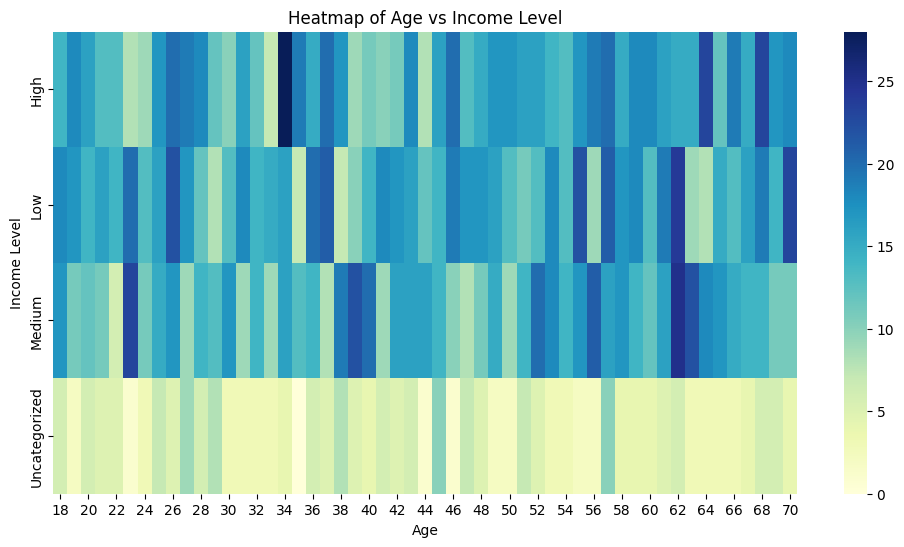

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create a pivot table (cross-tabulation) for the counts of Age vs. IncomeLevel
heatmap_data = pd.crosstab(cust_demo2['IncomeLevel'], cust_demo2['Age'])

# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=False, cbar=True)
plt.title('Heatmap of Age vs Income Level')
plt.xlabel('Age')
plt.ylabel('Income Level')
plt.show()


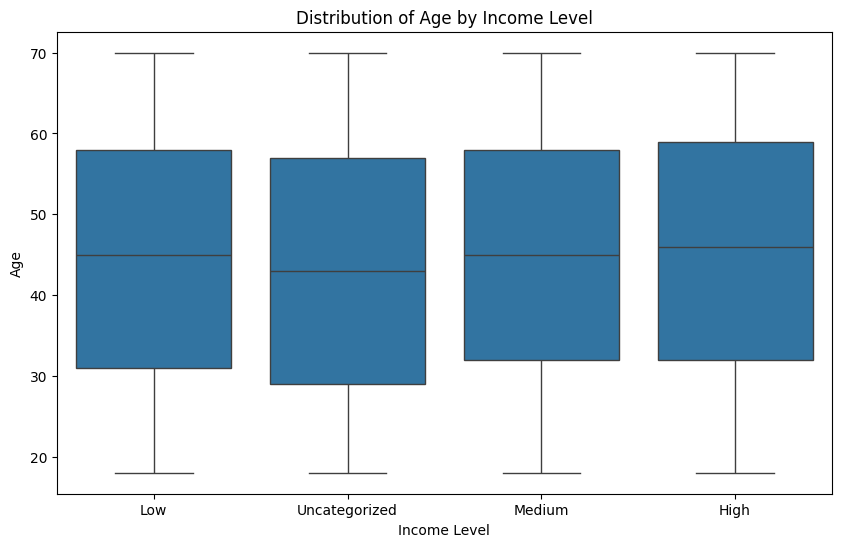

In [ ]:
# Plot a boxplot to visualize the distribution of Age across Income Levels
plt.figure(figsize=(10, 6))
sns.boxplot(x='IncomeLevel', y='Age', data=cust_demo2)
plt.title('Distribution of Age by Income Level')
plt.xlabel('Income Level')
plt.ylabel('Age')
plt.show()


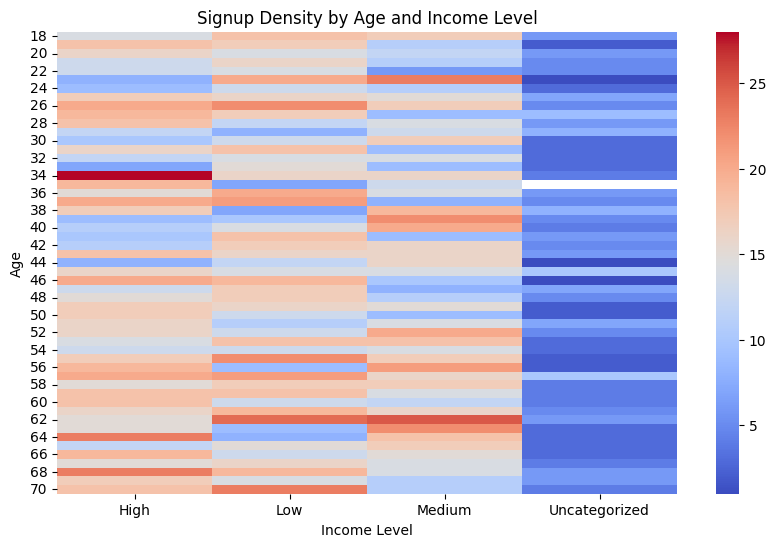

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(cust_demo2.pivot_table(index='Age', columns='IncomeLevel', aggfunc='size'), cmap='coolwarm')
plt.title('Signup Density by Age and Income Level')
plt.xlabel('Income Level')
plt.ylabel('Age')
plt.show()


In [12]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Assuming the customer demographics dataset is already loaded into 'customer_demographics'
# Sample dataset 'customer_demographics' contains 'Age' column.

# Define the age groups and corresponding labels
age_bins = [0, 12, 19, 39, 59, 99]
age_labels = ['Babies/Children (0-12)', 'Teens (13-19)', 'Young Adults (20-39)', 'Middle-aged Adults (40-59)', 'Old Adults (60-99)']

# Group data by AgeGroup to count the number of customers in each category
age_group_counts = customer_demographics['AgeGroup'].value_counts().reindex(age_labels)

# Create a bar chart using Plotly
# Pass the index directly as df.index for x-axis
fig = px.bar(
    age_group_counts,  # Use age_group_counts directly
    x=age_group_counts.index,  # Use .index to access the age group labels
    y=age_group_counts.values,  # Use .values to access the count data for the y-axis
    labels={'x': 'Age Group', 'y': 'Number of Customers'}, # Changed 'AgeGroup' to 'y'
    title='Customer Distribution by Age Group',
    color=age_group_counts.index,  # Using color based on Age Group categories
    color_discrete_sequence=px.colors.qualitative.Set2  # Similar palette to Seaborn 'Set2'
)



# Rotate x-axis labels for readability
fig.update_xaxes(tickangle=45)

# Show the plot
fig.show()

<ipython-input-30-6e01bcf34454>:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




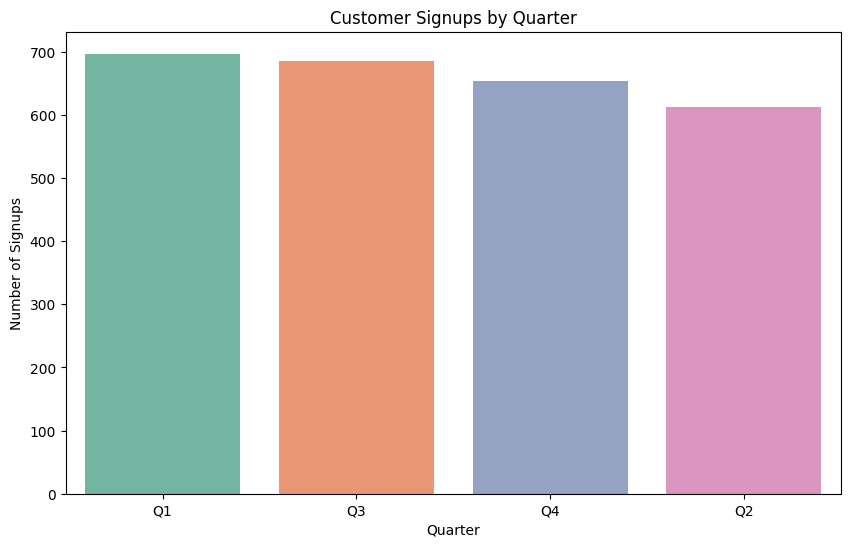

The quarter with the most signups is Q1 with 697 signups.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'cust_demo2' dataset has 'SignupMonth' column which contains the month names
# If the column is named something else, replace 'SignupMonth' with the actual column name.

# Create a dictionary to map each month to its corresponding quarter
month_to_quarter = {
    'January': 'Q1', 'February': 'Q1', 'March': 'Q1',
    'April': 'Q2', 'May': 'Q2', 'June': 'Q2',
    'July': 'Q3', 'August': 'Q3', 'September': 'Q3',
    'October': 'Q4', 'November': 'Q4', 'December': 'Q4'
}

# **Change:** Replace 'Month' with 'SignupMonth' (or the actual column name)
cust_demo2['SignupQuarter'] = cust_demo2['SignupMonth'].map(month_to_quarter)

# Count the number of signups per quarter
signup_per_quarter = cust_demo2['SignupQuarter'].value_counts().reset_index()
signup_per_quarter.columns = ['Quarter', 'SignupCount']

# Plot the signups per quarter
plt.figure(figsize=(10, 6))
sns.barplot(x='Quarter', y='SignupCount', data=signup_per_quarter, palette='Set2')
plt.title('Customer Signups by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Number of Signups')
plt.show()

# Display which quarter has the most signups
most_signups_quarter = signup_per_quarter.loc[signup_per_quarter['SignupCount'].idxmax()]
print(f"The quarter with the most signups is {most_signups_quarter['Quarter']} with {most_signups_quarter['SignupCount']} signups.")

<ipython-input-31-b0c57fba6251>:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




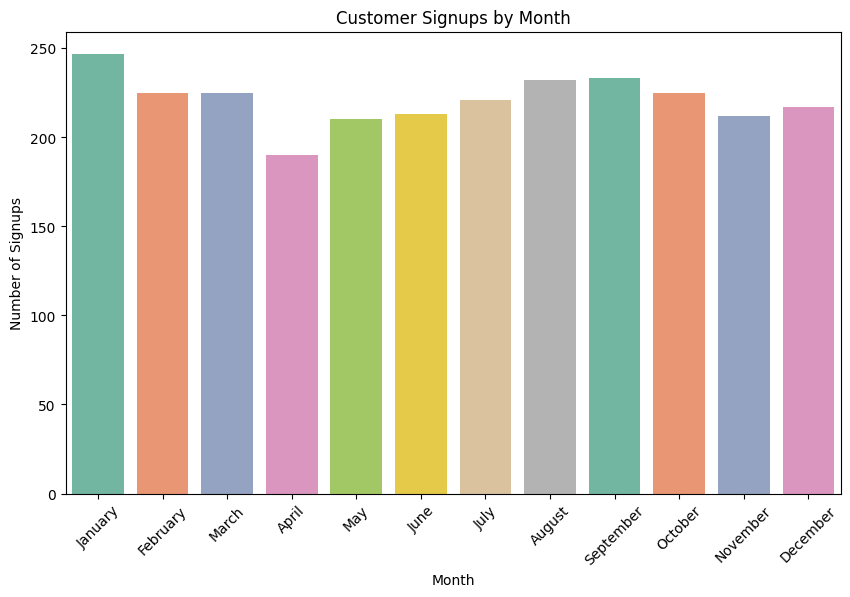

The month with the most signups is January with 247 signups.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'cust_demo2' dataset has 'SignupMonth' column which contains the month names
# If the column is named something else, replace 'SignupMonth' with the actual column name.

# Count the number of signups per month
signup_per_month = cust_demo2['SignupMonth'].value_counts().reset_index()
signup_per_month.columns = ['Month', 'SignupCount']

# Sort the months in calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
signup_per_month['Month'] = pd.Categorical(signup_per_month['Month'], categories=month_order, ordered=True)
signup_per_month = signup_per_month.sort_values('Month')

# Plot the signups per month
plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='SignupCount', data=signup_per_month, palette='Set2')
plt.title('Customer Signups by Month')
plt.xlabel('Month')
plt.ylabel('Number of Signups')
plt.xticks(rotation=45)
plt.show()

# Display which month has the most signups
most_signups_month = signup_per_month.loc[signup_per_month['SignupCount'].idxmax()]
print(f"The month with the most signups is {most_signups_month['Month']} with {most_signups_month['SignupCount']} signups.")


## **Customer Transactions**

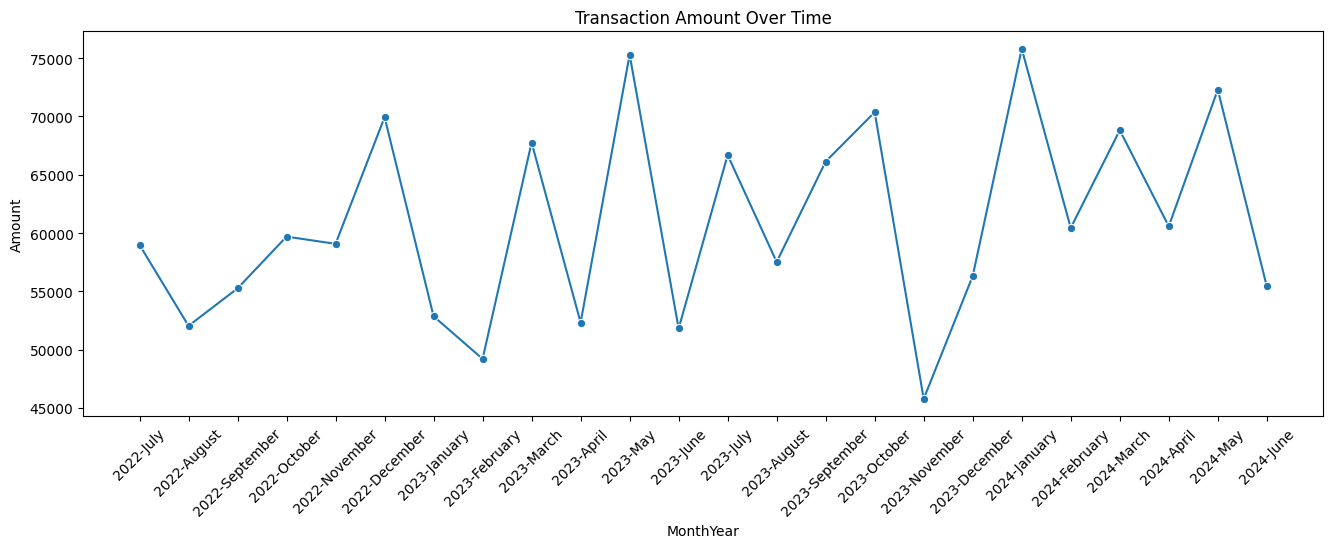

<ipython-input-32-fb3a3fa6280d>:45: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




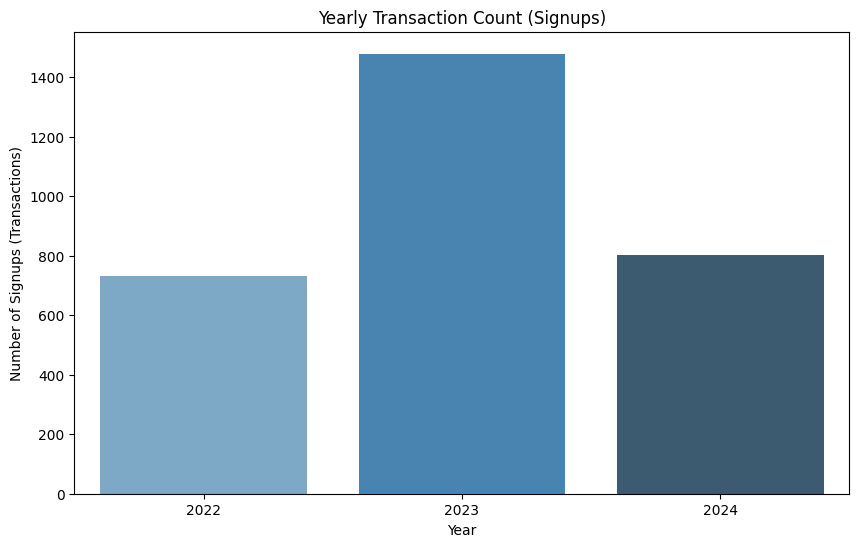

<ipython-input-32-fb3a3fa6280d>:59: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




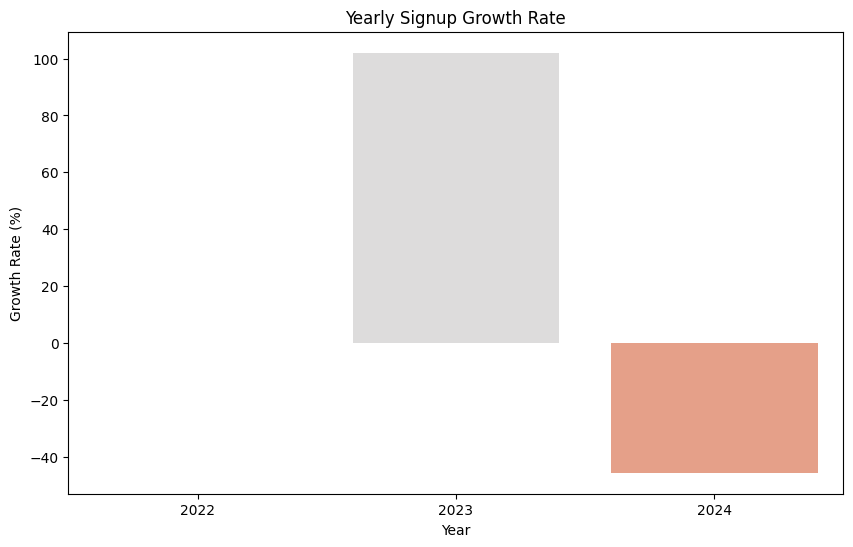

   Year  YearlySignups  GrowthRate
0  2022            732         NaN
1  2023           1479  102.049180
2  2024            804  -45.638945


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Convert 'TransactionDate' to datetime format
customer_transactions['TransactionDate'] = pd.to_datetime(customer_transactions['TransactionDate'], format='mixed')

# Extract Year and Month from the 'TransactionDate'
customer_transactions['Year'] = customer_transactions['TransactionDate'].dt.year
customer_transactions['Month'] = customer_transactions['TransactionDate'].dt.month_name()

# Create 'MonthYear' column for better grouping in the x-axis
customer_transactions['MonthYear'] = customer_transactions['Year'].astype(str) + '-' + customer_transactions['Month'].astype(str)

# Sort the data by 'TransactionDate' to maintain chronological order
customer_transactions.sort_values(by='TransactionDate', inplace=True)

# ----------------------------------
# Plot: Monthly Transaction Amounts
# ----------------------------------
# Set the figure size for the plot
plt.figure(figsize=(16, 5))

# Create a line plot of total transaction amount over time, grouped by 'MonthYear'
sns.lineplot(data=customer_transactions, x='MonthYear', y='Amount', estimator='sum', errorbar=None, marker="o")

# Set plot title and labels
plt.title('Transaction Amount Over Time')
plt.xticks(rotation=45)

# Show the plot
plt.show()

# ---------------------------------
# Calculate Yearly Signups (or transactions)
# ---------------------------------
# Group by 'Year' and count the number of transactions per year
yearly_signups = customer_transactions.groupby('Year').size().reset_index(name='YearlySignups')

# Plot yearly signups
plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='YearlySignups', data=yearly_signups, palette='Blues_d')
plt.title('Yearly Transaction Count (Signups)')
plt.xlabel('Year')
plt.ylabel('Number of Signups (Transactions)')
plt.show()

# ---------------------------------
# Calculate Signup Growth Rate
# ---------------------------------
# Calculate year-over-year growth rate
yearly_signups['GrowthRate'] = yearly_signups['YearlySignups'].pct_change() * 100

# Plot signup growth rate
plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='GrowthRate', data=yearly_signups, palette='coolwarm')
plt.title('Yearly Signup Growth Rate')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.show()

# Display the final Yearly Signups with Growth Rate
print(yearly_signups)


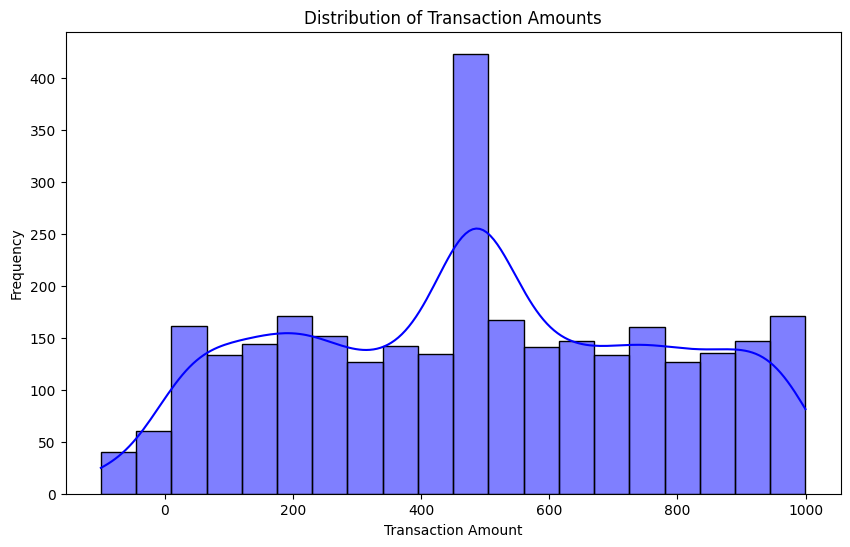

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(customer_transactions['Amount'], bins=20, kde=True, color='blue')
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()


<ipython-input-34-9504bfbb5323>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




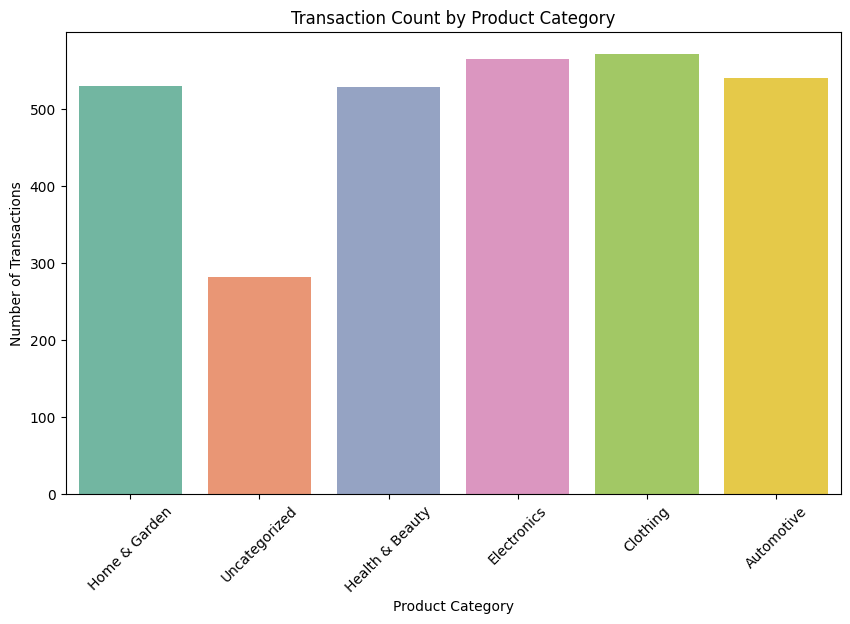

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='ProductCategory', data=customer_transactions, palette='Set2')
plt.title('Transaction Count by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()


<ipython-input-35-227b001f94e4>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




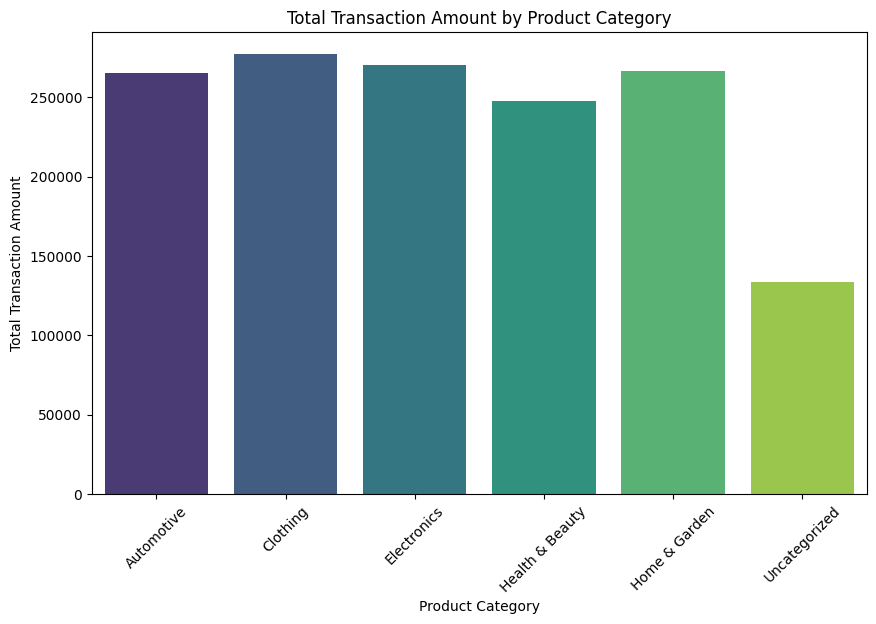

In [ ]:
plt.figure(figsize=(10, 6))
total_by_category = customer_transactions.groupby('ProductCategory')['Amount'].sum().reset_index()
sns.barplot(x='ProductCategory', y='Amount', data=total_by_category, palette='viridis')
plt.title('Total Transaction Amount by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Transaction Amount')
plt.xticks(rotation=45)
plt.show()


<ipython-input-36-aa2288e101af>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




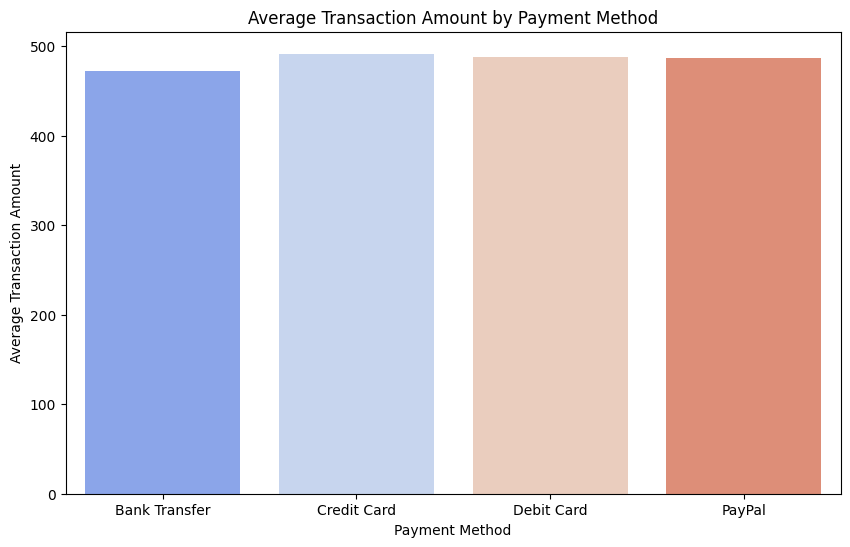

In [ ]:
plt.figure(figsize=(10, 6))
avg_by_payment = customer_transactions.groupby('PaymentMethod')['Amount'].mean().reset_index()
sns.barplot(x='PaymentMethod', y='Amount', data=avg_by_payment, palette='coolwarm')
plt.title('Average Transaction Amount by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Transaction Amount')
plt.show()


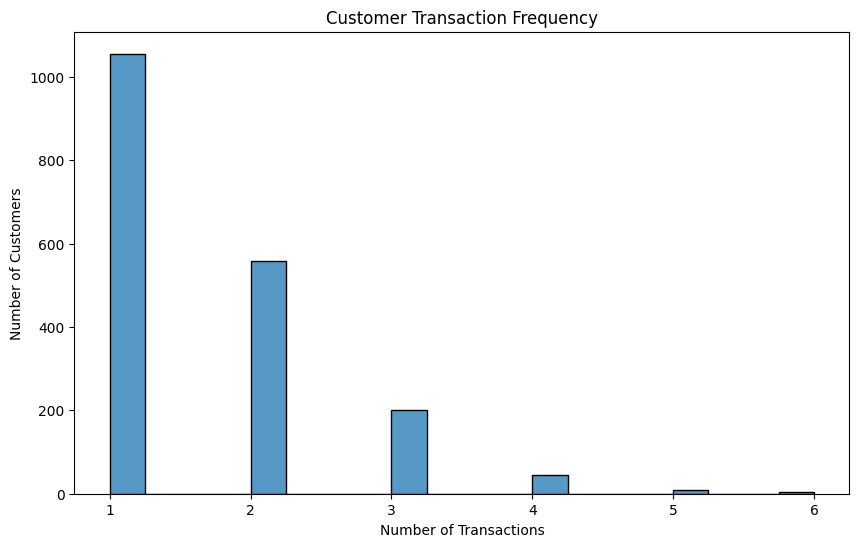

In [ ]:
plt.figure(figsize=(10, 6))
transaction_freq = customer_transactions['CustomerID'].value_counts().reset_index()
transaction_freq.columns = ['CustomerID', 'TransactionCount']

sns.histplot(transaction_freq['TransactionCount'], bins=20, kde=False)
plt.title('Customer Transaction Frequency')
plt.xlabel('Number of Transactions')
plt.ylabel('Number of Customers')
plt.show()


<ipython-input-38-3dfb87ea967f>:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




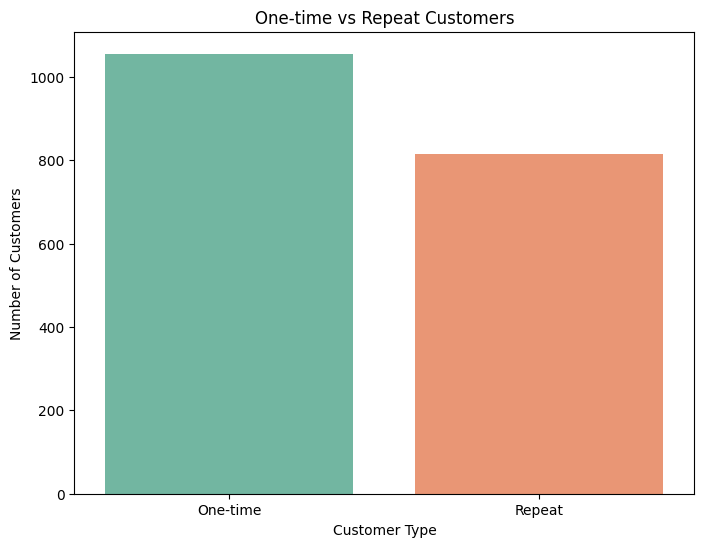

One-time customers: 1056
Repeat customers: 815


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Count the number of transactions per customer
customer_transaction_counts = customer_transactions['CustomerID'].value_counts()

# Classify customers as 'One-time' or 'Repeat'
customer_transaction_status = customer_transaction_counts.apply(lambda x: 'Repeat' if x > 1 else 'One-time')

# Count how many customers are 'One-time' and how many are 'Repeat'
customer_status_counts = customer_transaction_status.value_counts()

# Plot the bar chart to show the number of One-time vs Repeat customers
plt.figure(figsize=(8, 6))
sns.barplot(x=customer_status_counts.index, y=customer_status_counts.values, palette='Set2')
plt.title('One-time vs Repeat Customers')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')
plt.show()

# Print out the exact numbers for one-time and repeat customers
print(f"One-time customers: {customer_status_counts['One-time']}")
print(f"Repeat customers: {customer_status_counts['Repeat']}")


<ipython-input-39-3804bfc44202>:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




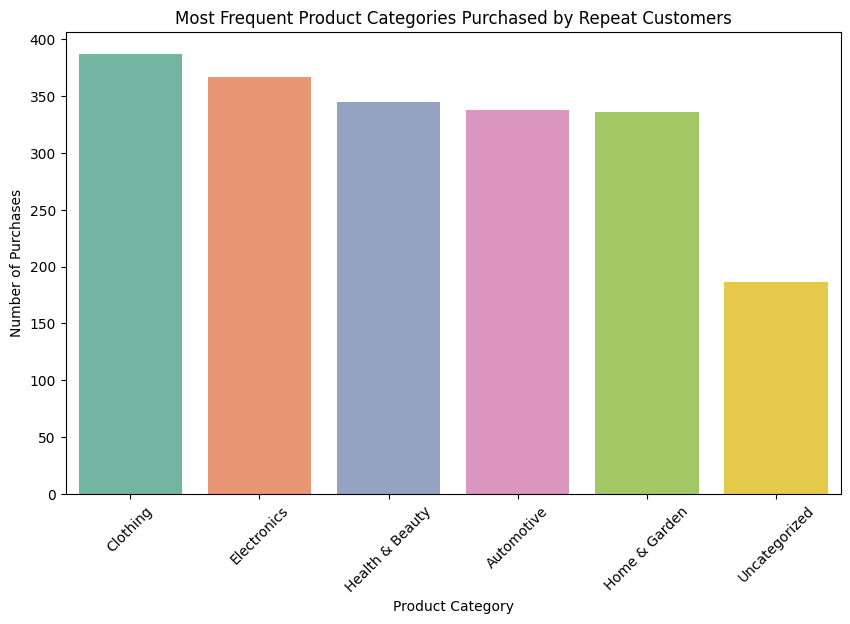

Top 5 product categories bought by repeat customers:
   ProductCategory  PurchaseCount
0         Clothing            387
1      Electronics            367
2  Health & Beauty            345
3       Automotive            338
4    Home & Garden            336


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Count the number of transactions per customer
customer_transaction_counts = customer_transactions['CustomerID'].value_counts()

# Identify repeat customers (those with more than 1 transaction)
repeat_customers = customer_transaction_counts[customer_transaction_counts > 1].index

# Filter the transactions to only include those from repeat customers
repeat_customer_transactions = customer_transactions[customer_transactions['CustomerID'].isin(repeat_customers)]

# Count the products or product categories bought by repeat customers
repeat_purchase_by_category = repeat_customer_transactions['ProductCategory'].value_counts().reset_index()
repeat_purchase_by_category.columns = ['ProductCategory', 'PurchaseCount']

# Plot the most frequently purchased product categories by repeat customers
plt.figure(figsize=(10, 6))
sns.barplot(x='ProductCategory', y='PurchaseCount', data=repeat_purchase_by_category, palette='Set2')
plt.title('Most Frequent Product Categories Purchased by Repeat Customers')
plt.xlabel('Product Category')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)
plt.show()

# Display top 5 product categories bought by repeat customers
print("Top 5 product categories bought by repeat customers:")
print(repeat_purchase_by_category.head(5))


<ipython-input-40-2baa1e2dcaca>:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




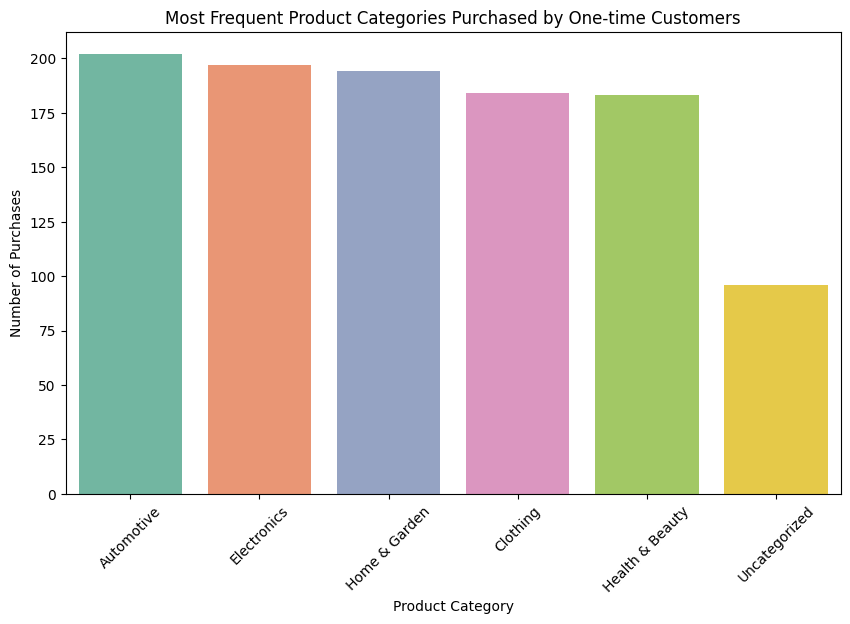

Top 5 product categories bought by one-time customers:
   ProductCategory  PurchaseCount
0       Automotive            202
1      Electronics            197
2    Home & Garden            194
3         Clothing            184
4  Health & Beauty            183


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Count the number of transactions per customer
customer_transaction_counts = customer_transactions['CustomerID'].value_counts()

# Identify one-time customers (those with only 1 transaction)
one_time_customers = customer_transaction_counts[customer_transaction_counts == 1].index

# Filter the transactions to only include those from one-time customers
one_time_customer_transactions = customer_transactions[customer_transactions['CustomerID'].isin(one_time_customers)]

# Count the products or product categories bought by one-time customers
one_time_purchase_by_category = one_time_customer_transactions['ProductCategory'].value_counts().reset_index()
one_time_purchase_by_category.columns = ['ProductCategory', 'PurchaseCount']

# Plot the most frequently purchased product categories by one-time customers
plt.figure(figsize=(10, 6))
sns.barplot(x='ProductCategory', y='PurchaseCount', data=one_time_purchase_by_category, palette='Set2')
plt.title('Most Frequent Product Categories Purchased by One-time Customers')
plt.xlabel('Product Category')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)
plt.show()

# Display top 5 product categories bought by one-time customers
print("Top 5 product categories bought by one-time customers:")
print(one_time_purchase_by_category.head(5))


<ipython-input-41-f4b2fa946fbf>:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




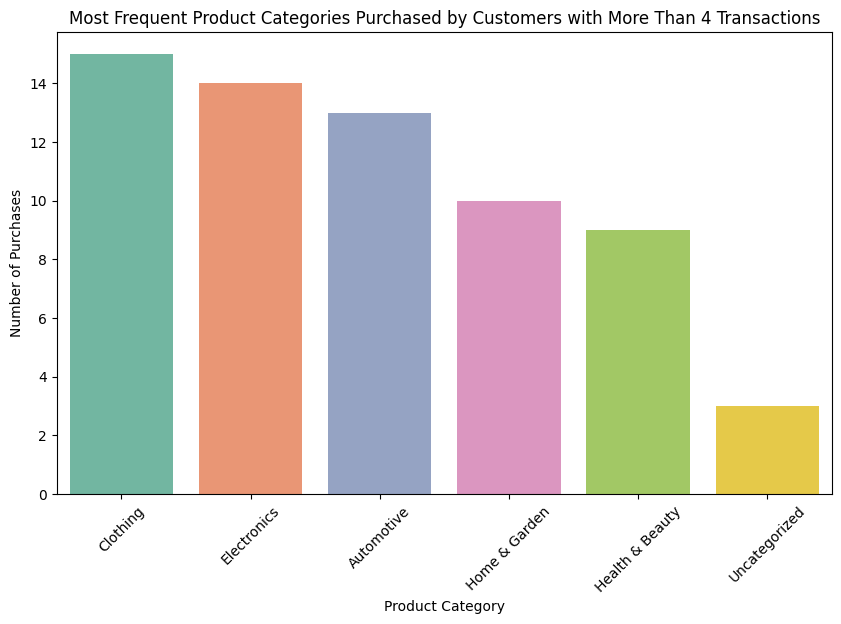

Top 5 product categories bought by customers with more than 4 transactions:
   ProductCategory  PurchaseCount
0         Clothing             15
1      Electronics             14
2       Automotive             13
3    Home & Garden             10
4  Health & Beauty              9


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Count the number of transactions per customer
customer_transaction_counts = customer_transactions['CustomerID'].value_counts()

# Identify customers with more than 4 transactions
high_transaction_customers = customer_transaction_counts[customer_transaction_counts > 4].index

# Filter the transactions to only include those from customers with more than 4 transactions
high_transaction_customer_transactions = customer_transactions[customer_transactions['CustomerID'].isin(high_transaction_customers)]

# Count the products or product categories bought by customers with more than 4 transactions
high_transaction_purchase_by_category = high_transaction_customer_transactions['ProductCategory'].value_counts().reset_index()
high_transaction_purchase_by_category.columns = ['ProductCategory', 'PurchaseCount']

# Plot the most frequently purchased product categories by customers with more than 4 transactions
plt.figure(figsize=(10, 6))
sns.barplot(x='ProductCategory', y='PurchaseCount', data=high_transaction_purchase_by_category, palette='Set2')
plt.title('Most Frequent Product Categories Purchased by Customers with More Than 4 Transactions')
plt.xlabel('Product Category')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)
plt.show()

# Display top 5 product categories bought by customers with more than 4 transactions
print("Top 5 product categories bought by customers with more than 4 transactions:")
print(high_transaction_purchase_by_category.head(5))


<ipython-input-42-f59d582fac39>:29: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




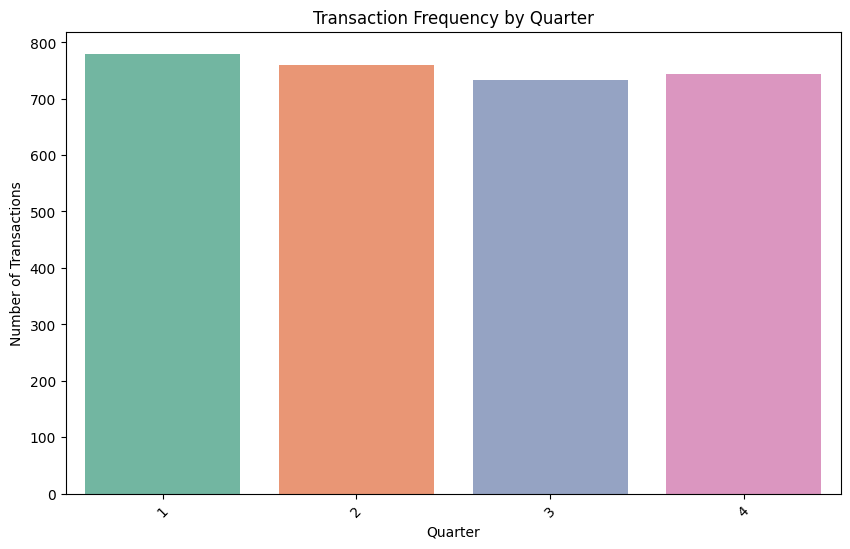

The quarter with the most transactions is Q1 with 780 transactions.


<ipython-input-42-f59d582fac39>:60: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




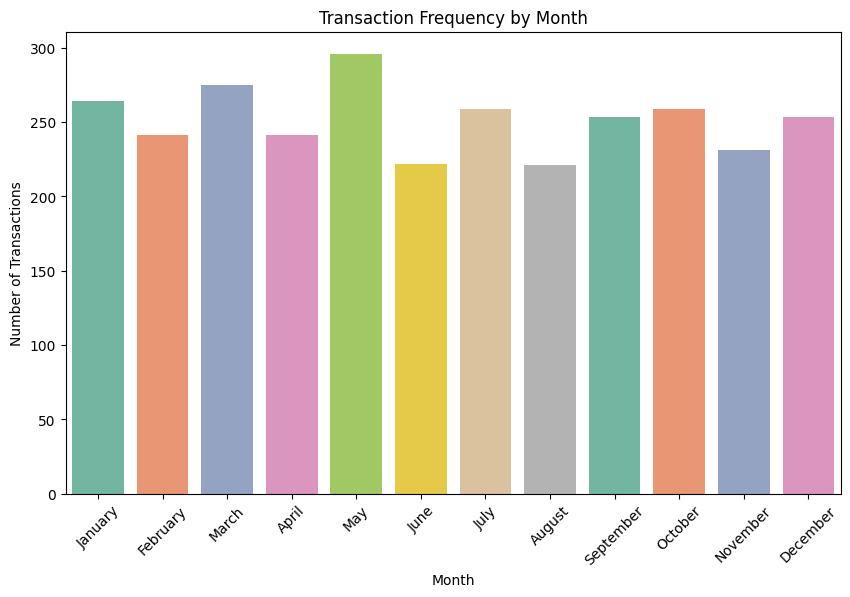

The month with the most transactions is May with 296 transactions.

Transaction counts per quarter:
   Quarter  TransactionCount
0        1               780
1        2               759
3        3               733
2        4               743

Transaction counts per month:
        Month  TransactionCount
2     January               264
8    February               241
1       March               275
7       April               241
0         May               296
10       June               222
3        July               259
11     August               221
5   September               253
4     October               259
9    November               231
6    December               253


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Convert 'TransactionDate' to datetime format
customer_transactions['TransactionDate'] = pd.to_datetime(customer_transactions['TransactionDate'])

# Extract the quarter (just Q1, Q2, Q3, Q4) from 'TransactionDate'
customer_transactions['Quarter'] = customer_transactions['TransactionDate'].dt.quarter

# ---------------------------
# Frequency of Transactions per Quarter (Q1, Q2, Q3, Q4)
# ---------------------------
# Count the number of transactions per quarter
transaction_per_quarter = customer_transactions['Quarter'].value_counts().reset_index()
transaction_per_quarter.columns = ['Quarter', 'TransactionCount']

# Sort the quarters in order (Q1 to Q4)
transaction_per_quarter = transaction_per_quarter.sort_values('Quarter')

# Identify the quarter with the most transactions
most_transacted_quarter = transaction_per_quarter.loc[transaction_per_quarter['TransactionCount'].idxmax()]

# Plot the frequency of transactions per quarter
plt.figure(figsize=(10, 6))
sns.barplot(x='Quarter', y='TransactionCount', data=transaction_per_quarter, palette='Set2')
plt.title('Transaction Frequency by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

# Display the quarter with the most transactions
print(f"The quarter with the most transactions is Q{most_transacted_quarter['Quarter']} with {most_transacted_quarter['TransactionCount']} transactions.")

# ---------------------------
# Frequency of Transactions per Month
# ---------------------------
# Extract month names
customer_transactions['Month'] = customer_transactions['TransactionDate'].dt.month_name()

# Count the number of transactions per month
transaction_per_month = customer_transactions['Month'].value_counts().reset_index()
transaction_per_month.columns = ['Month', 'TransactionCount']

# Ensure the months are in the correct calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
transaction_per_month['Month'] = pd.Categorical(transaction_per_month['Month'], categories=month_order, ordered=True)
transaction_per_month = transaction_per_month.sort_values('Month')

# Identify the month with the most transactions
most_transacted_month = transaction_per_month.loc[transaction_per_month['TransactionCount'].idxmax()]

# Plot the frequency of transactions per month
plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='TransactionCount', data=transaction_per_month, palette='Set2')
plt.title('Transaction Frequency by Month')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

# Display the month with the most transactions
print(f"The month with the most transactions is {most_transacted_month['Month']} with {most_transacted_month['TransactionCount']} transactions.")

# Output the transaction counts per quarter and per month
print("\nTransaction counts per quarter:")
print(transaction_per_quarter)

print("\nTransaction counts per month:")
print(transaction_per_month)


## **Social Media Interaction**

In [ ]:
import pandas as pd

# Load datasets
customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')
socmed_interactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df3.csv')

# Ensure all CustomerID columns are of the same data type
socmed_interactions['CustomerID'] = socmed_interactions['CustomerID'].astype(str)
customer_transactions['CustomerID'] = customer_transactions['CustomerID'].astype(str)

# 1. Identify customers who interacted on social media
interacted_customers = socmed_interactions['CustomerID'].unique()

# 2. Identify customers who made purchases
purchasing_customers = customer_transactions['CustomerID'].unique()

# 3. Find customers who interacted and also made a purchase (intersection of both sets)
interacted_and_purchased = set(interacted_customers).intersection(set(purchasing_customers))

# 4. Calculate conversion rate
total_interacted = len(interacted_customers)
total_converted = len(interacted_and_purchased)

conversion_rate = (total_converted / total_interacted) * 100

# Output the conversion rate
print(f"Total Customers Who Interacted: {total_interacted}")
print(f"Total Customers Who Interacted and Purchased: {total_converted}")
print(f"Conversion Rate from Social Media Interactions to Purchases: {conversion_rate:.2f}%")


Total Customers Who Interacted: 1893
Total Customers Who Interacted and Purchased: 1181
Conversion Rate from Social Media Interactions to Purchases: 62.39%


In [ ]:
import pandas as pd

# Load datasets
customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')
socmed_interactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df3.csv')

# Ensure all CustomerID columns are of the same data type
socmed_interactions['CustomerID'] = socmed_interactions['CustomerID'].astype(str)
customer_transactions['CustomerID'] = customer_transactions['CustomerID'].astype(str)

# 1. Left join social media interactions with customer transactions based on CustomerID
# This will keep all interactions and bring in transaction data where available
merged_data = pd.merge(socmed_interactions, customer_transactions, on='CustomerID', how='left')

# 2. Identify customers who interacted and made a purchase
# Customers who made a purchase will have non-null 'TransactionID'
customers_interacted_and_purchased = merged_data[merged_data['TransactionID'].notnull()]['CustomerID'].nunique()

# 3. Total number of customers who interacted (before the merge)
total_interacted_customers = socmed_interactions['CustomerID'].nunique()

# 4. Calculate conversion rate
conversion_rate = (customers_interacted_and_purchased / total_interacted_customers) * 100

# Output the conversion rate
print(f"Total Customers Who Interacted: {total_interacted_customers}")
print(f"Total Customers Who Interacted and Purchased: {customers_interacted_and_purchased}")
print(f"Conversion Rate from Social Media Interactions to Purchases: {conversion_rate:.2f}%")


Total Customers Who Interacted: 1893
Total Customers Who Interacted and Purchased: 1181
Conversion Rate from Social Media Interactions to Purchases: 62.39%


In [ ]:
import pandas as pd

# Load datasets (replace with actual file paths or data)
customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')
socmed_interactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df3.csv')


# Ensure CustomerID is of the same type
socmed_interactions['CustomerID'] = socmed_interactions['CustomerID'].astype(str)
customer_transactions['CustomerID'] = customer_transactions['CustomerID'].astype(str)
customer_demographics['CustomerID'] = customer_demographics['CustomerID'].astype(str)

# Step 1: Perform a LEFT JOIN between socialmedia (socmed_interactions) and customer transactions (CustTrx)
left_joined_data = pd.merge(socmed_interactions, customer_transactions, on='CustomerID', how='left')

# Step 2: Perform another LEFT JOIN between the result and customer demographics (CustDemo)
final_merged_data = pd.merge(left_joined_data, customer_demographics, on='CustomerID', how='left')

# Step 3: Filter for customers present in all datasets
# Customers must have non-null 'TransactionID' and non-null demographic info
present_in_all = final_merged_data[final_merged_data['TransactionID'].notnull() & final_merged_data['CustomerID'].notnull()]

# Step 4: Count how many customers interacted on social media
total_interacted_customers = socmed_interactions['CustomerID'].nunique()

# Step 5: Count how many customers are present in all datasets (those who bought something)
customers_in_all_datasets = present_in_all['CustomerID'].nunique()

# Step 6: Calculate conversion rate
conversion_rate = (customers_in_all_datasets / total_interacted_customers) * 100

# Output the results
print(f"Total Customers Who Interacted: {total_interacted_customers}")
print(f"Total Customers Present in All Datasets (Interacted and Bought): {customers_in_all_datasets}")
print(f"Conversion Rate from Social Media Interactions to Purchases: {conversion_rate:.2f}%")


Total Customers Who Interacted: 1893
Total Customers Present in All Datasets (Interacted and Bought): 1181
Conversion Rate from Social Media Interactions to Purchases: 62.39%


In [ ]:
import pandas as pd

# Load datasets (replace with actual file paths or data)
customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')
socmed_interactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df3.csv')


# Ensure CustomerID is of the same type across all datasets
socmed_interactions['CustomerID'] = socmed_interactions['CustomerID'].astype(str)
customer_transactions['CustomerID'] = customer_transactions['CustomerID'].astype(str)
customer_demographics['CustomerID'] = customer_demographics['CustomerID'].astype(str)

# Step 1: Perform a LEFT JOIN between social media interactions and customer transactions
left_joined_data = pd.merge(socmed_interactions, customer_transactions, on='CustomerID', how='left')

# Step 2: Perform another LEFT JOIN between the result and customer demographics
final_merged_data = pd.merge(left_joined_data, customer_demographics, on='CustomerID', how='left')

# Step 3: Filter for customers present in all datasets (i.e., with non-null TransactionID and non-null CustomerID)
present_in_all = final_merged_data[final_merged_data['TransactionID'].notnull() & final_merged_data['CustomerID'].notnull()]

# Step 4: Count unique CustomerIDs who interacted on social media
total_unique_interacted_customers = socmed_interactions['CustomerID'].nunique()

# Step 5: Count unique CustomerIDs who are present in all datasets (those who made purchases)
unique_customers_in_all_datasets = present_in_all['CustomerID'].nunique()

# Step 6: Calculate conversion rate based on unique CustomerIDs
conversion_rate = (unique_customers_in_all_datasets / total_unique_interacted_customers) * 100

# Output the results
print(f"Total Unique Customers Who Interacted: {total_unique_interacted_customers}")
print(f"Total Unique Customers Present in All Datasets (Interacted and Bought): {unique_customers_in_all_datasets}")
print(f"Conversion Rate from Social Media Interactions to Purchases (Unique Customers): {conversion_rate:.2f}%")


Total Unique Customers Who Interacted: 1893
Total Unique Customers Present in All Datasets (Interacted and Bought): 1181
Conversion Rate from Social Media Interactions to Purchases (Unique Customers): 62.39%
